# Switch Transformer vs. Vanilla Transformer
### TinyStories Dataset

**Course**: Advanced NLP Lab

**TA**: Emilio Villa

This notebook implements both a **Switch Transformer** ([Fedus et al., 2021](https://arxiv.org/abs/2101.03961)) and a standard **Vanilla Transformer** baseline for character-level language modeling on the **TinyStories** dataset.

We compare the two models using **perplexity** ($\text{PPL} = e^{\mathcal{L}_{\text{CE}}}$) on train and validation splits.

### Dataset: TinyStories
- Source: [roneneldan/TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories)
- A dataset of short stories generated by GPT-3.5/GPT-4, designed for training small language models
- Contains ~2.1M stories with simple vocabulary and grammar
- We pick a small subset of stories.

### Key ideas behind the Switch Transformer
- Each transformer layer replaces the single FFN with $N$ *expert* FFNs.
- A lightweight *router* (a learned linear layer + softmax) sends each token to exactly **one** expert (top-1 routing).
- A **capacity factor** limits how many tokens each expert can process, with optional **token dropping** when an expert is over capacity.
- A **load-balancing loss** $\mathcal{L}_{\text{lb}} = N \sum_i f_i \cdot P_i$ encourages even token distribution across experts.

#### You are tasked to complete the code snippet marked as ##TODO

---
## 1. Imports, Device Setup & Dataset

In [1]:
import copy
import math
import random
from pathlib import Path
from typing import List, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler
import matplotlib.pyplot as plt
import numpy as np

# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ── Download TinyStories Dataset ─────────────────────────────────────────────
from datasets import load_dataset

print("Loading TinyStories dataset...")
# Load a subset for faster training (you can remove num_proc and take_first for full dataset)
dataset = load_dataset("roneneldan/TinyStories", split="train")

# Take a subset for manageable training time
dataset = dataset.select(range(2500))

# Concatenate all stories into one large text corpus
print("Concatenating stories...")
raw_text = "\n\n".join([story["text"] for story in dataset])

print(f"Dataset size: {len(raw_text):,} characters")
print(f"Number of stories: {len(dataset):,}")

# ── Character-level tokenizer ────────────────────────────────────────────────
chars = sorted(list(set(raw_text)))
n_vocab = len(chars)
stoi: Dict[str, int] = {ch: i for i, ch in enumerate(chars)}
itos: List[str] = chars

print(f"Vocabulary size: {n_vocab}")
print(f"Sample chars: {chars[:20]}")


def encode(text: str) -> torch.Tensor:
    """Encode a string into a tensor of character indices."""
    return torch.tensor([stoi[ch] for ch in text if ch in stoi], dtype=torch.long)


def decode(indices) -> str:
    """Decode a tensor/list of indices back into a string."""
    return "".join([itos[i] for i in indices])


# ── Train / Validation split (95/5 since dataset is larger) ──────────────────
split_idx = int(len(raw_text) * 0.95)
train_text = raw_text[:split_idx]
valid_text = raw_text[split_idx:]

train_data = encode(train_text)
valid_data = encode(valid_text)

print(f"Train tokens: {len(train_data):,}  |  Valid tokens: {len(valid_data):,}")

Loading TinyStories dataset...
Concatenating stories...
Dataset size: 2,230,567 characters
Number of stories: 2,500
Vocabulary size: 90
Sample chars: ['\n', ' ', '!', '"', '$', "'", ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':']
Train tokens: 2,119,038  |  Valid tokens: 111,529


In [3]:
# ── Dataset & DataLoader ────────────────────────────────────────────────────
SEQ_LEN = 64
BATCH_SIZE = 128


class CharDataset(Dataset):
    """Chunks the tokenized text into non-overlapping segments of `seq_len`.
    Each sample returns (data, target) where target is data shifted by 1.
    A small random offset is added for data augmentation."""

    def __init__(self, data: torch.Tensor, seq_len: int):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, idx):
        start = idx * self.seq_len
        # Random offset for augmentation (don't exceed bounds)
        max_offset = min(
            self.seq_len - 1,
            len(self.data) - (start + self.seq_len + 1),
        )
        if max_offset > 0:
            start += random.randint(0, max_offset)
        end = start + self.seq_len
        return self.data[start:end], self.data[start + 1 : end + 1]


def transpose_batch(batch):
    """Collate function: stack into [seq_len, batch_size] (sequence-first)."""
    src = torch.stack([b[0] for b in batch], dim=1)
    tgt = torch.stack([b[1] for b in batch], dim=1)
    return src, tgt


train_dataset = CharDataset(train_data, SEQ_LEN)
valid_dataset = CharDataset(valid_data, SEQ_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=RandomSampler(train_dataset),
    collate_fn=transpose_batch,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    sampler=RandomSampler(valid_dataset),
    collate_fn=transpose_batch,
)

print(f"Train batches: {len(train_loader)}  |  Valid batches: {len(valid_loader)}")

Train batches: 259  |  Valid batches: 14


---
## 2. Shared Building Blocks

These modules are used by **both** the vanilla and switch transformer:
- `subsequent_mask` — causal (lower-triangular) mask for autoregressive attention
- `PositionalEncoding` — sinusoidal positional encodings (Vaswani et al.)
- `FeedForward` — standard two-layer MLP (Linear → ReLU → Dropout → Linear)
- `MultiHeadAttention` — scaled dot-product multi-head attention (sequence-first layout)

In [4]:
# ── Utilities ────────────────────────────────────────────────────────────────

def clone_module_list(module: nn.Module, n: int) -> nn.ModuleList:
    """Create an nn.ModuleList with `n` deep copies of `module`."""
    return nn.ModuleList([copy.deepcopy(module) for _ in range(n)])


def subsequent_mask(seq_len: int) -> torch.Tensor:
    """Lower-triangular causal mask of shape [seq_len, seq_len].
    Position i can attend to positions 0..i."""
    return torch.tril(torch.ones(seq_len, seq_len)).bool()


# ── Positional Encoding ──────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017).
    Adds position information to token embeddings.

    PE(pos, 2i)   = sin(pos / 10000^{2i/d_model})
    PE(pos, 2i+1) = cos(pos / 10000^{2i/d_model})
    """

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Shape: [max_len, 1, d_model]  (sequence-first with broadcast batch dim)
        pe = pe.unsqueeze(1)
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: [seq_len, batch_size, d_model]"""
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


# ── Feed-Forward Network ────────────────────────────────────────────────────

class FeedForward(nn.Module):
    """Position-wise feed-forward network: Linear(d_model→d_ff) → ReLU → Dropout → Linear(d_ff→d_model)"""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.layer1 = nn.Linear(d_model, d_ff)
        self.layer2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer2(self.dropout(self.activation(self.layer1(x))))


# ── Multi-Head Attention ─────────────────────────────────────────────────────

class PrepareForMultiHeadAttention(nn.Module):
    """Linear projection that reshapes input into [*, heads, d_k]."""

    def __init__(self, d_model: int, heads: int, d_k: int, bias: bool = True):
        super().__init__()
        self.linear = nn.Linear(d_model, heads * d_k, bias=bias)
        self.heads = heads
        self.d_k = d_k

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [seq_len, batch_size, d_model]
        head_shape = x.shape[:-1]  # [seq_len, batch_size]
        x = self.linear(x)
        return x.view(*head_shape, self.heads, self.d_k)


class MultiHeadAttention(nn.Module):
    """Scaled dot-product multi-head attention.
    Expects inputs in sequence-first layout: [seq_len, batch_size, d_model].
    Uses einsum for the attention computation."""

    def __init__(self, heads: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.d_k = d_model // heads
        self.heads = heads
        self.query = PrepareForMultiHeadAttention(d_model, heads, self.d_k, bias=True)
        self.key = PrepareForMultiHeadAttention(d_model, heads, self.d_k, bias=True)
        self.value = PrepareForMultiHeadAttention(d_model, heads, self.d_k, bias=True)
        self.softmax = nn.Softmax(dim=1)  # softmax over key dimension (dim=1 after einsum gives [i,j,b,h])
        self.output = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = 1.0 / math.sqrt(self.d_k)

    def forward(
        self,
        *,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        seq_len, batch_size, _ = query.shape

        # Project to [seq_len, batch_size, heads, d_k]
        q = self.query(query)
        k = self.key(key)
        v = self.value(value)

        # Attention scores: [query_len, key_len, batch_size, heads]
        scores = torch.einsum("ibhd,jbhd->ijbh", q, k) * self.scale

        # Apply causal mask
        if mask is not None:
            # mask shape: [seq_len, seq_len] → unsqueeze to broadcast over batch & heads
            # scores shape: [query_len, key_len, batch_size, heads]
            scores = scores.masked_fill(mask.unsqueeze(-1).unsqueeze(-1) == 0, float("-inf"))

        # Softmax over key dimension (dim=1)
        attn = self.softmax(scores)
        attn = self.dropout(attn)

        # Weighted sum: [query_len, batch_size, heads, d_k]
        x = torch.einsum("ijbh,jbhd->ibhd", attn, v)

        # Concatenate heads: [seq_len, batch_size, d_model]
        x = x.reshape(seq_len, batch_size, -1)
        return self.output(x)


print("Building blocks defined ✓")

Building blocks defined ✓


---
## 3. Vanilla Transformer (Baseline)

A standard decoder-only transformer for autoregressive language modeling.

Each layer uses **pre-norm** (LayerNorm *before* attention/FFN, not after):
```
x ─→ LN ─→ Self-Attn ─→ (+x) ─→ LN ─→ FFN ─→ (+x) ─→
```

In [5]:
class TransformerLayer(nn.Module):
    """A single pre-norm transformer decoder layer."""

    def __init__(self, d_model: int, attn: MultiHeadAttention,
                 feed_forward: FeedForward, dropout: float):
        super().__init__()
        self.size = d_model
        self.attn = attn
        self.feed_forward = feed_forward
        self.dropout = nn.Dropout(dropout)
        self.norm_attn = nn.LayerNorm(d_model)
        self.norm_ff = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # Pre-norm self-attention + residual
        z = self.norm_attn(x)
        x = x + self.dropout(self.attn(query=z, key=z, value=z, mask=mask))
        # Pre-norm FFN + residual
        z = self.norm_ff(x)
        x = x + self.dropout(self.feed_forward(z))
        return x


class TransformerEncoder(nn.Module):
    """Stack of TransformerLayers + final LayerNorm."""

    def __init__(self, layer: TransformerLayer, n_layers: int):
        super().__init__()
        self.layers = clone_module_list(layer, n_layers)
        self.norm = nn.LayerNorm(layer.size)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


class VanillaTransformerModel(nn.Module):
    """Autoregressive model: Embedding → PositionalEncoding → TransformerEncoder → Linear.
    Returns logits of shape [seq_len, batch_size, n_vocab]."""

    def __init__(self, n_vocab: int, d_model: int, encoder: TransformerEncoder, dropout: float):
        super().__init__()
        self.embedding = nn.Embedding(n_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.encoder = encoder
        self.generator = nn.Linear(d_model, n_vocab)
        self._mask = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: [seq_len, batch_size] of token indices → logits [seq_len, batch_size, n_vocab]"""
        seq_len = x.size(0)
        if self._mask is None or self._mask.size(0) != seq_len:
            self._mask = subsequent_mask(seq_len).to(x.device)
        x = self.embedding(x)  # [seq_len, batch, d_model]
        x = self.pos_enc(x)
        x = self.encoder(x, self._mask)
        return self.generator(x)


print("Vanilla Transformer defined ✓")

Vanilla Transformer defined ✓


---
## 4. Switch Transformer (Mixture of Experts)

The key difference: the FFN in each layer is replaced by **`SwitchFeedForward`**, which contains $N$ independent expert FFNs and a learned **router**.

**Routing procedure** (for each token independently):
1. Compute routing probabilities: $p(x) = \text{softmax}(W_r \cdot x)$ where $p \in \mathbb{R}^N$
2. Assign each token to its top-1 expert: $\text{expert}(x) = \arg\max_i \, p_i(x)$
3. Each expert has a **capacity** = `capacity_factor × (total_tokens / n_experts)`. Excess tokens are dropped (passed through unchanged).
4. Expert output is optionally **scaled** by the routing probability $p_{\text{expert}(x)}(x)$.

**Load-balancing loss** (per layer, summed across layers):
$$\mathcal{L}_{\text{lb}} = N \sum_{i=1}^{N} f_i \cdot P_i$$
where $f_i$ is the fraction of tokens routed to expert $i$ and $P_i$ is the mean routing probability for expert $i$.

Complete the ```TODO``` sections on SwitchFeedForward() and in the loss computation based on equations above.

In [6]:
class SwitchFeedForward(nn.Module):
    """
    
    Switch feed-forward: routes each token to one of `n_experts` FFNs.
    
    """

    def __init__(
        self,
        *,
        capacity_factor: float,
        drop_tokens: bool,
        is_scale_prob: bool,
        n_experts: int,
        expert: FeedForward,
        d_model: int,
    ):
        super().__init__()
        self.capacity_factor = capacity_factor
        self.is_scale_prob = is_scale_prob
        self.n_experts = n_experts
        self.drop_tokens = drop_tokens
        # Create n_experts independent copies of the expert FFN
        self.experts = clone_module_list(expert, n_experts)
        # Router: linear layer that produces n_experts logits per token
        self.switch = nn.Linear(d_model, n_experts)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x: torch.Tensor):
        """x: [seq_len, batch_size, d_model]
        Returns: (output, counts, route_prob_sum, n_dropped, route_prob_max)
        """
        seq_len, batch_size, d_model = x.shape
        # Flatten to [seq_len * batch_size, d_model]
        x = x.view(-1, d_model)
        num_tokens = x.shape[0]

        # Router: compute routing probabilities
        route_prob = self.softmax(self.switch(x))  # [num_tokens, n_experts]
   

        # Top-1 routing: pick the expert with highest probability for each token
        route_prob_max, routes = torch.max(route_prob, dim=-1)  # [num_tokens]

        # Group token indices by their assigned expert
        indexes_list = [
            torch.eq(routes, i).nonzero(as_tuple=True)[0]
            for i in range(self.n_experts)
        ]

        # Prepare output buffer
        final_output = x.new_zeros(x.shape)

        # Capacity: max tokens each expert can handle

        capacity = int(self.capacity_factor * ((num_tokens + self.n_experts - 1) // self.n_experts))
   

        # Count how many tokens were routed to each expert
        counts = x.new_tensor([len(indexes_list[i]) for i in range(self.n_experts)])

        # Drop tokens that exceed capacity (if enabled)
        dropped = []
        if self.drop_tokens:
            for i in range(self.n_experts):
                if len(indexes_list[i]) <= capacity:
                    continue
                # Shuffle and keep only `capacity` tokens; drop the rest
                indexes_list[i] = indexes_list[i][torch.randperm(len(indexes_list[i]))]
                dropped.append(indexes_list[i][capacity:])
                indexes_list[i] = indexes_list[i][:capacity]

        # Run each expert on its assigned tokens
        expert_output = [
            self.experts[i](x[indexes_list[i], :])
            for i in range(self.n_experts)
        ]

        # Scatter expert outputs back to the correct positions
        for i in range(self.n_experts):
            final_output[indexes_list[i], :] = expert_output[i]

        # For dropped tokens, pass the input through unchanged
        if dropped:
            dropped = torch.cat(dropped)
            final_output[dropped, :] = x[dropped, :]

        # Scale outputs by routing probability
        if self.is_scale_prob:
            # Scale by the routing probability (straight-through)
            final_output = final_output * route_prob_max.view(-1, 1)
        else:
            # Scale by p / detach(p) — gradient flows through router only
            final_output = final_output * (route_prob_max / route_prob_max.detach()).view(-1, 1)

        # Reshape back to [seq_len, batch_size, d_model]
        final_output = final_output.view(seq_len, batch_size, d_model)

        n_dropped = len(dropped) if isinstance(dropped, torch.Tensor) else sum(len(d) for d in dropped)
        return final_output, counts, route_prob.sum(0), n_dropped, route_prob_max


class SwitchTransformerLayer(nn.Module):
    """Pre-norm transformer layer with SwitchFeedForward instead of regular FFN."""

    def __init__(self, d_model: int, attn: MultiHeadAttention,
                 feed_forward: SwitchFeedForward, dropout: float):
        super().__init__()
        self.size = d_model
        self.attn = attn
        self.feed_forward = feed_forward
        self.dropout = nn.Dropout(dropout)
        self.norm_attn = nn.LayerNorm(d_model)
        self.norm_ff = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        # Pre-norm self-attention + residual
        z = self.norm_attn(x)
        x = x + self.dropout(self.attn(query=z, key=z, value=z, mask=mask))
        # Pre-norm switch FFN + residual
        z = self.norm_ff(x)
        ff, counts, route_prob, n_dropped, route_prob_max = self.feed_forward(z)
        x = x + self.dropout(ff)
        return x, counts, route_prob, n_dropped, route_prob_max


class SwitchTransformer(nn.Module):
    """Stack of SwitchTransformerLayers + final LayerNorm.
    Aggregates routing statistics across all layers."""

    def __init__(self, layer: SwitchTransformerLayer, n_layers: int):
        super().__init__()
        self.layers = clone_module_list(layer, n_layers)
        self.norm = nn.LayerNorm(layer.size)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        counts, route_prob, n_dropped, route_prob_max = [], [], [], []
        for layer in self.layers:
            x, c, rp, nd, rpm = layer(x, mask)
            counts.append(c)
            route_prob.append(rp)
            n_dropped.append(nd)
            route_prob_max.append(rpm)
        x = self.norm(x)
        return x, torch.stack(counts), torch.stack(route_prob), n_dropped, torch.stack(route_prob_max)


class SwitchTransformerModel(nn.Module):
    """Autoregressive wrapper for the Switch Transformer.
    Returns (logits, counts, route_prob, n_dropped, route_prob_max)."""

    def __init__(self, n_vocab: int, d_model: int, switch_transformer: SwitchTransformer, dropout: float):
        super().__init__()
        self.embedding = nn.Embedding(n_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.transformer = switch_transformer
        self.generator = nn.Linear(d_model, n_vocab)
        self._mask = None

    def forward(self, x: torch.Tensor):
        """x: [seq_len, batch_size] → (logits, counts, route_prob, n_dropped, route_prob_max)"""
        seq_len = x.size(0)
        if self._mask is None or self._mask.size(0) != seq_len:
            self._mask = subsequent_mask(seq_len).to(x.device)
        x = self.embedding(x)
        x = self.pos_enc(x)
        x, counts, route_prob, n_dropped, route_prob_max = self.transformer(x, self._mask)
        logits = self.generator(x)
        return logits, counts, route_prob, n_dropped, route_prob_max


print("Switch Transformer defined ✓")

Switch Transformer defined ✓


---
## 5. Model Instantiation

We create both models with identical core hyperparameters so the comparison is fair.

> **Note on parameter count**: The Switch Transformer has *more* total parameters (4 expert FFNs instead of 1), but each token only activates one expert per layer. This is the key insight — you get a larger model capacity while keeping per-token FLOPs roughly constant.

In [7]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
D_MODEL = 128
HEADS = 4
D_FF = 256
N_LAYERS = 6
DROPOUT = 0.1
EPOCHS = 50
LR = 1e-3
GRAD_CLIP = 1.0

# Switch-specific
N_EXPERTS = 4
CAPACITY_FACTOR = 1.2
DROP_TOKENS = True
IS_SCALE_PROB = True
LOAD_BALANCING_COEFF = 0.01


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Vanilla Transformer ──────────────────────────────────────────────────────
vanilla_layer = TransformerLayer(
    d_model=D_MODEL,
    attn=MultiHeadAttention(HEADS, D_MODEL, DROPOUT),
    feed_forward=FeedForward(D_MODEL, D_FF, DROPOUT),
    dropout=DROPOUT,
)
vanilla_encoder = TransformerEncoder(vanilla_layer, N_LAYERS)
vanilla_model = VanillaTransformerModel(n_vocab, D_MODEL, vanilla_encoder, DROPOUT).to(device)

# ── Switch Transformer ───────────────────────────────────────────────────────
switch_layer = SwitchTransformerLayer(
    d_model=D_MODEL,
    attn=MultiHeadAttention(HEADS, D_MODEL, DROPOUT),
    feed_forward=SwitchFeedForward(
        capacity_factor=CAPACITY_FACTOR,
        drop_tokens=DROP_TOKENS,
        is_scale_prob=IS_SCALE_PROB,
        n_experts=N_EXPERTS,
        expert=FeedForward(D_MODEL, D_FF, DROPOUT),
        d_model=D_MODEL,
    ),
    dropout=DROPOUT,
)
switch_core = SwitchTransformer(switch_layer, N_LAYERS)
switch_model = SwitchTransformerModel(n_vocab, D_MODEL, switch_core, DROPOUT).to(device)

print(f"Vanilla Transformer — {count_parameters(vanilla_model):,} parameters")
print(f"Switch Transformer  — {count_parameters(switch_model):,} parameters")
print(f"\nParameter ratio (Switch / Vanilla): {count_parameters(switch_model) / count_parameters(vanilla_model):.2f}x")

Vanilla Transformer — 818,266 parameters
Switch Transformer  — 2,007,922 parameters

Parameter ratio (Switch / Vanilla): 2.45x


---
## 6. Training & Evaluation Loop

We define reusable `train_one_epoch` and `evaluate` functions.

- **Both models** are trained with cross-entropy loss.
- **Switch Transformer** additionally receives a load-balancing loss:
  $\mathcal{L} = \mathcal{L}_{\text{CE}} + \alpha \cdot \mathcal{L}_{\text{lb}}$  where $\alpha = 0.01$
- **Perplexity** = $e^{\text{avg CE loss}}$ — lower is better.

Reminder: **Load-balancing loss** (per layer, summed across layers):
$$\mathcal{L}_{\text{lb}} = N \sum_{i=1}^{N} f_i \cdot P_i$$

In [8]:
loss_fn = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer, is_switch=False):
    """Train for one epoch. Returns average CE loss."""
    model.train()
    total_loss = 0.0
    n_batches = 0

    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()

        if is_switch:
            output, counts, route_prob, n_dropped, route_prob_max = model(data)

            # Cross-entropy loss between model output and target
            ce_loss = loss_fn(output.view(-1, output.size(-1)), target.view(-1))

            # Compute total number of tokens processed per layer: [n_layers, 1]
            total_tokens = counts.sum(dim=1, keepdim=True)

            # Calculate the fraction of tokens routed to each expert for each layer: [n_layers, n_experts]
            route_frac = counts / (total_tokens + 1e-9)

            # Compute the mean routing probability for each expert in each layer: [n_layers, n_experts]
            route_prob_mean = route_prob.mean(dim=0)

            # Expand shape if necessary to align for load-balancing calculation
            if route_frac.shape != route_prob_mean.shape:
                route_prob_mean = route_prob_mean.expand_as(route_frac)

            # Calculate the load-balancing loss as in Switch Transformer (MoE)
            lb_loss = (route_frac * route_prob_mean).sum()

            # Incorporate all terms in the final loss
            loss = ce_loss + 0.01 * lb_loss

            # Optionally, you may log or utilize n_dropped and route_prob_max for diagnostic purposes.
        else:
            output = model(data)
            ce_loss = loss_fn(output.view(-1, output.size(-1)), target.view(-1))
            loss = ce_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        total_loss += ce_loss.item()
        n_batches += 1

    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader, is_switch=False):
    """Evaluate on a data loader. Returns average CE loss."""
    model.eval()
    total_loss = 0.0
    n_batches = 0

    for data, target in loader:
        data, target = data.to(device), target.to(device)

        if is_switch:
            output, *_ = model(data)
        else:
            output = model(data)

        ce_loss = loss_fn(output.view(-1, output.size(-1)), target.view(-1))
        total_loss += ce_loss.item()
        n_batches += 1

    return total_loss / n_batches


def train_model(model, name, is_switch=False):
    """Full training loop for `EPOCHS` epochs. Returns history dict."""
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}

    print(f"\n{'='*60}")
    print(f"Training {name} for {EPOCHS} epochs")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, is_switch=is_switch)
        val_loss = evaluate(model, valid_loader, is_switch=is_switch)

        train_ppl = math.exp(train_loss)
        val_ppl = math.exp(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_ppl"].append(train_ppl)
        history["val_ppl"].append(val_ppl)

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  Epoch {epoch:3d}/{EPOCHS} │ "
                f"Train Loss: {train_loss:.4f}  PPL: {train_ppl:7.2f} │ "
                f"Val Loss: {val_loss:.4f}  PPL: {val_ppl:7.2f}"
            )

    print(f"  {'─'*56}")
    print(
        f"  Final │ Train PPL: {history['train_ppl'][-1]:.2f} │ Val PPL: {history['val_ppl'][-1]:.2f}"
    )
    return history


print("Training functions defined ✓")

Training functions defined ✓


---
## 7. Train Both Models

In [9]:
vanilla_history = train_model(vanilla_model, "Vanilla Transformer", is_switch=False)


Training Vanilla Transformer for 50 epochs
  Epoch   1/50 │ Train Loss: 2.2124  PPL:    9.14 │ Val Loss: 1.6723  PPL:    5.32
  Epoch   5/50 │ Train Loss: 1.3351  PPL:    3.80 │ Val Loss: 1.1518  PPL:    3.16
  Epoch  10/50 │ Train Loss: 1.1972  PPL:    3.31 │ Val Loss: 1.0486  PPL:    2.85
  Epoch  15/50 │ Train Loss: 1.1415  PPL:    3.13 │ Val Loss: 0.9972  PPL:    2.71
  Epoch  20/50 │ Train Loss: 1.1062  PPL:    3.02 │ Val Loss: 0.9695  PPL:    2.64
  Epoch  25/50 │ Train Loss: 1.0843  PPL:    2.96 │ Val Loss: 0.9541  PPL:    2.60
  Epoch  30/50 │ Train Loss: 1.0676  PPL:    2.91 │ Val Loss: 0.9423  PPL:    2.57
  Epoch  35/50 │ Train Loss: 1.0541  PPL:    2.87 │ Val Loss: 0.9342  PPL:    2.55
  Epoch  40/50 │ Train Loss: 1.0450  PPL:    2.84 │ Val Loss: 0.9231  PPL:    2.52
  Epoch  45/50 │ Train Loss: 1.0346  PPL:    2.81 │ Val Loss: 0.9201  PPL:    2.51
  Epoch  50/50 │ Train Loss: 1.0281  PPL:    2.80 │ Val Loss: 0.9063  PPL:    2.48
  ─────────────────────────────────────────

In [10]:
switch_history = train_model(switch_model, "Switch Transformer", is_switch=True)


Training Switch Transformer for 50 epochs


  Epoch   1/50 │ Train Loss: 2.4686  PPL:   11.81 │ Val Loss: 2.0019  PPL:    7.40
  Epoch   5/50 │ Train Loss: 1.4575  PPL:    4.30 │ Val Loss: 1.2684  PPL:    3.56
  Epoch  10/50 │ Train Loss: 1.2688  PPL:    3.56 │ Val Loss: 1.1009  PPL:    3.01
  Epoch  15/50 │ Train Loss: 1.1857  PPL:    3.27 │ Val Loss: 1.0449  PPL:    2.84
  Epoch  20/50 │ Train Loss: 1.1348  PPL:    3.11 │ Val Loss: 1.0011  PPL:    2.72
  Epoch  25/50 │ Train Loss: 1.0974  PPL:    3.00 │ Val Loss: 0.9721  PPL:    2.64
  Epoch  30/50 │ Train Loss: 1.0708  PPL:    2.92 │ Val Loss: 0.9535  PPL:    2.59
  Epoch  35/50 │ Train Loss: 1.0495  PPL:    2.86 │ Val Loss: 0.9351  PPL:    2.55
  Epoch  40/50 │ Train Loss: 1.0319  PPL:    2.81 │ Val Loss: 0.9226  PPL:    2.52
  Epoch  45/50 │ Train Loss: 1.0174  PPL:    2.77 │ Val Loss: 0.9108  PPL:    2.49
  Epoch  50/50 │ Train Loss: 1.0041  PPL:    2.73 │ Val Loss: 0.8969  PPL:    2.45
  ────────────────────────────────────────────────────────
  Final │ Train PPL: 2.73 │ 

---
## 8. Results: Perplexity Comparison

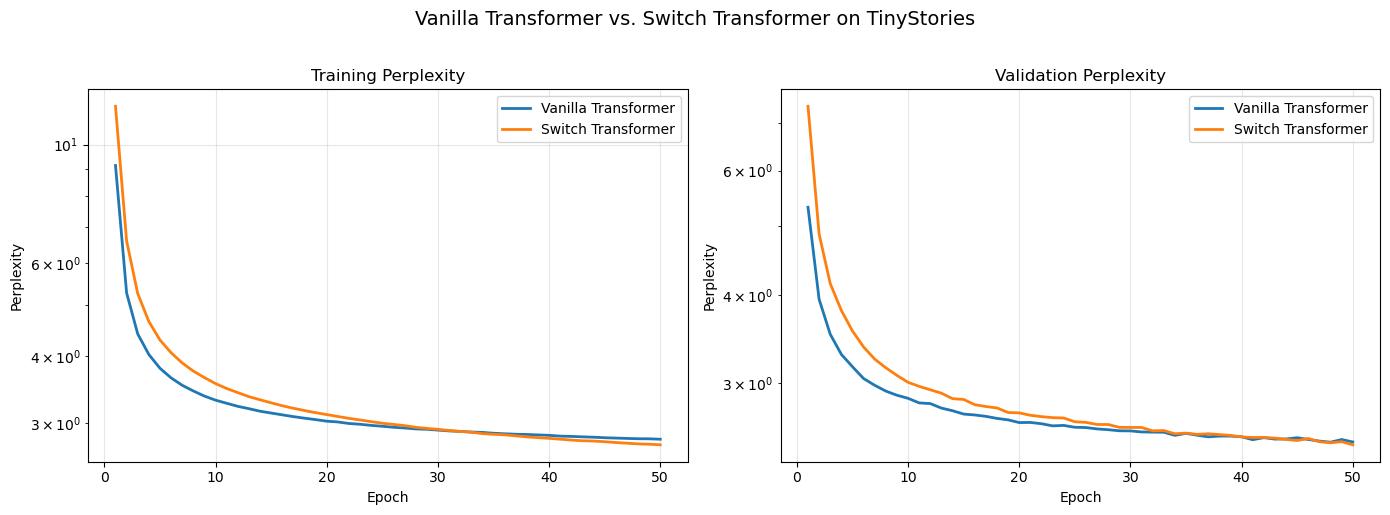


Model                        Train PPL      Val PPL     Parameters
───────────────────────────────────────────────────────────────
Vanilla Transformer               2.80         2.48        818,266
Switch Transformer                2.73         2.45      2,007,922


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# ── Training Perplexity ───────────────────────────────────────────────────────
axes[0].plot(epochs_range, vanilla_history["train_ppl"], label="Vanilla Transformer", linewidth=2)
axes[0].plot(epochs_range, switch_history["train_ppl"], label="Switch Transformer", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Perplexity")
axes[0].set_title("Training Perplexity")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")

# ── Validation Perplexity ─────────────────────────────────────────────────────
axes[1].plot(epochs_range, vanilla_history["val_ppl"], label="Vanilla Transformer", linewidth=2)
axes[1].plot(epochs_range, switch_history["val_ppl"], label="Switch Transformer", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Validation Perplexity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")

plt.suptitle("Vanilla Transformer vs. Switch Transformer on TinyStories", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary Table ─────────────────────────────────────────────────────────────
print(f"\n{'Model':<25} {'Train PPL':>12} {'Val PPL':>12} {'Parameters':>14}")
print(f"{'─'*63}")
print(
    f"{'Vanilla Transformer':<25} "
    f"{vanilla_history['train_ppl'][-1]:>12.2f} "
    f"{vanilla_history['val_ppl'][-1]:>12.2f} "
    f"{count_parameters(vanilla_model):>14,}"
)
print(
    f"{'Switch Transformer':<25} "
    f"{switch_history['train_ppl'][-1]:>12.2f} "
    f"{switch_history['val_ppl'][-1]:>12.2f} "
    f"{count_parameters(switch_model):>14,}"
)

In [12]:
# save models and histories
torch.save({
    "vanilla_model_state": vanilla_model.state_dict(),
    "switch_model_state": switch_model.state_dict(),
    "vanilla_history": vanilla_history,
    "switch_history": switch_history,
}, "switch_transformer_tinystories.pth")


---
## 9. Text Generation (Sampling)

Let's generate some text from both trained models to qualitatively compare outputs.

In [13]:
@torch.no_grad()
def generate(model, prompt: str, max_len: int = 200, temperature: float = 0.8, is_switch: bool = False) -> str:
    """Autoregressively generate text from a prompt."""
    model.eval()
    tokens = [stoi[ch] for ch in prompt if ch in stoi]

    for _ in range(max_len):
        # Use at most the last SEQ_LEN tokens as context
        context = tokens[-SEQ_LEN:]
        x = torch.tensor(context, dtype=torch.long).unsqueeze(1).to(device)  # [seq_len, 1]

        if is_switch:
            logits, *_ = model(x)
        else:
            logits = model(x)

        # Take logits at the last position, apply temperature
        logits = logits[-1, 0, :] / temperature
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1).item()
        tokens.append(next_token)

    return decode(tokens)


PROMPT = "Once upon a time, there was a"

print("=" * 60)
print("VANILLA TRANSFORMER")
print("=" * 60)
print(generate(vanilla_model, PROMPT, is_switch=False))

print("\n" + "=" * 60)
print("SWITCH TRANSFORMER")
print("=" * 60)
print(generate(switch_model, PROMPT, is_switch=True))

VANILLA TRANSFORMER
Once upon a time, there was a garden who had a new friend. It was now that being cutton. He started to go home, but the spot started the boy would chose the ball and said, "That is walking in the park in the carrot and the car ca

SWITCH TRANSFORMER
Once upon a time, there was a little girl named Lucy. She loved to wear the same things. One day, she was talking to the bugs and when her mommy asked her mom if they played with their truck. She loved happily over the universing


---
## 10. Router Visualization

Let's visualize how the Switch Transformer's routing mechanism works by examining which experts are selected for each token in a given prompt. This helps us understand the specialization that emerges during training.

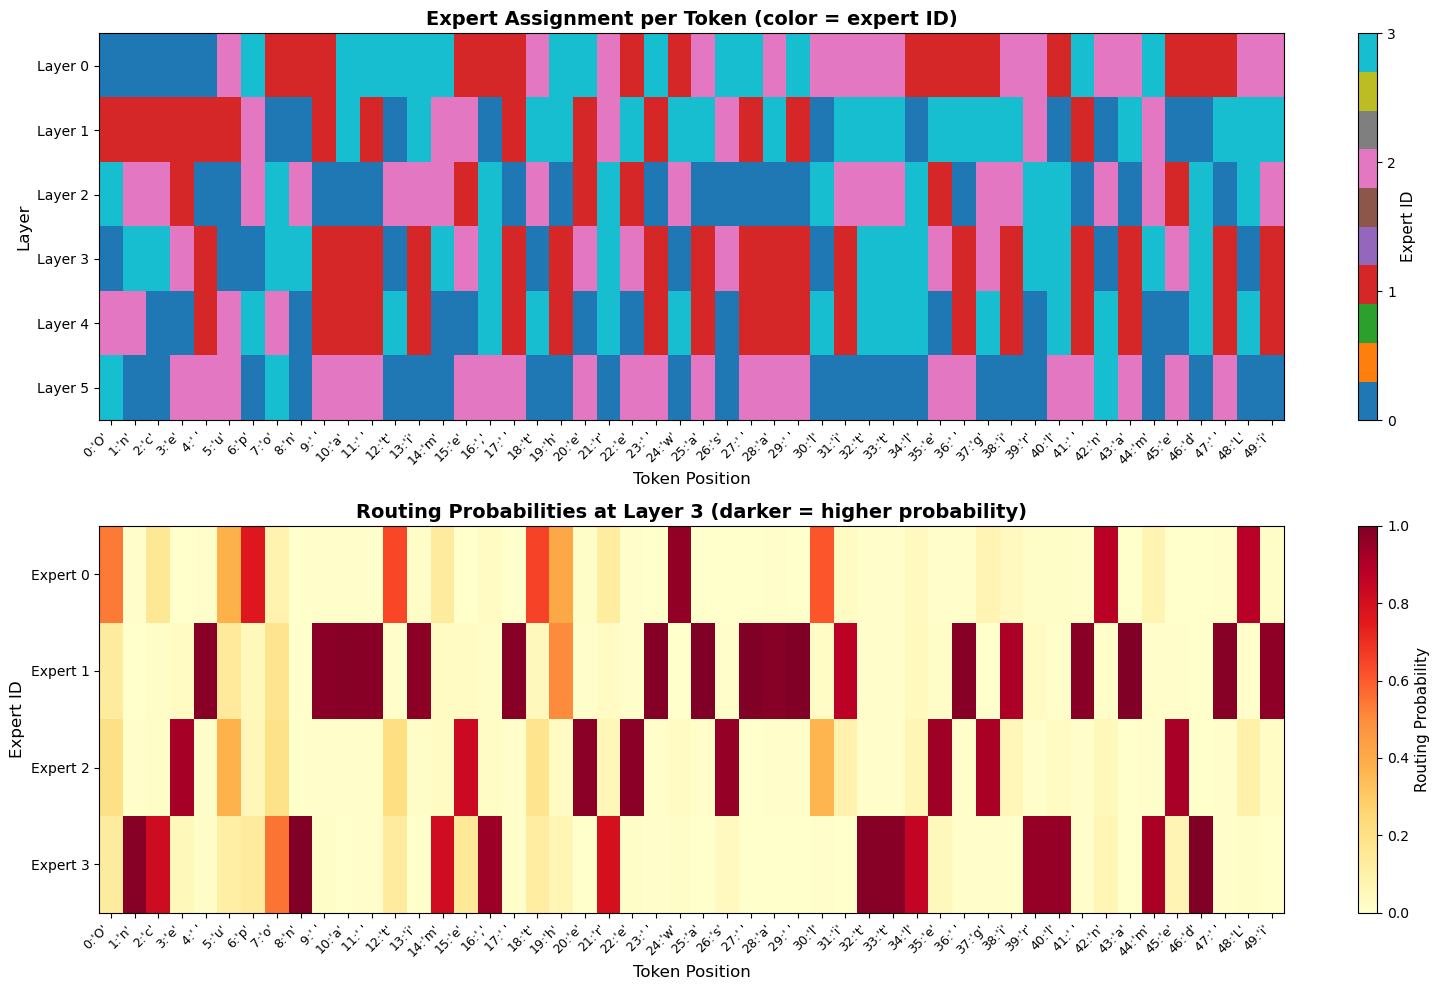


ROUTING STATISTICS for prompt: 'Once upon a time, there was a little girl named Lily.'

Tokens analyzed: 50
Prompt: Once upon a time, there was a little girl named Li

Expert Usage per Layer:
Layer        Expert 0   Expert 1   Expert 2   Expert 3
--------------------------------------------------
Layer 0        10.0%      32.0%      30.0%      28.0%
Layer 1        20.0%      28.0%      14.0%      38.0%
Layer 2        34.0%      12.0%      34.0%      20.0%
Layer 3        18.0%      38.0%      16.0%      28.0%
Layer 4        24.0%      38.0%       8.0%      30.0%
Layer 5        48.0%       0.0%      46.0%       6.0%

Overall Expert Usage (across all layers):
  Expert 0:  25.7% (77 / 300 tokens)
  Expert 1:  24.7% (74 / 300 tokens)
  Expert 2:  24.7% (74 / 300 tokens)
  Expert 3:  25.0% (75 / 300 tokens)


In [14]:
@torch.no_grad()
def visualize_routing(model, prompt: str, max_tokens: int = 60):
    """Visualize which experts are selected for each token across all layers."""
    model.eval()
    
    # Encode the prompt
    tokens = [stoi[ch] for ch in prompt if ch in stoi]
    tokens = tokens[:max_tokens]  # Limit length
    
    # Prepare input tensor [seq_len, 1]
    x = torch.tensor(tokens, dtype=torch.long).unsqueeze(1).to(device)
    seq_len = x.size(0)
    
    # Forward pass through embedding and positional encoding
    x_embed = model.embedding(x)
    x_embed = model.pos_enc(x_embed)
    
    # Create mask
    mask = subsequent_mask(seq_len).to(device)
    
    # Collect routing decisions from each layer
    routing_decisions = []  # [n_layers, seq_len] - expert index for each token
    routing_probs = []       # [n_layers, seq_len, n_experts] - probabilities
    
    x = x_embed
    for layer_idx, layer in enumerate(model.transformer.layers):
        # Self-attention
        z = layer.norm_attn(x)
        x = x + layer.dropout(layer.attn(query=z, key=z, value=z, mask=mask))
        
        # Switch FFN - we need to extract routing info
        z = layer.norm_ff(x)
        
        # Get routing probabilities from the switch layer
        z_flat = z.view(-1, D_MODEL)
        route_prob = F.softmax(layer.feed_forward.switch(z_flat), dim=-1)  # [seq_len, n_experts]
        route_prob_max, routes = torch.max(route_prob, dim=-1)
        
        routing_decisions.append(routes.cpu().numpy())
        routing_probs.append(route_prob.cpu().numpy())
        
        # Continue forward pass
        ff_output, _, _, _, _ = layer.feed_forward(z)
        x = x + layer.dropout(ff_output)
    
    routing_decisions = np.array(routing_decisions)  # [n_layers, seq_len]
    routing_probs = np.array(routing_probs)          # [n_layers, seq_len, n_experts]
    
    # ── Visualization ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Plot 1: Heatmap of expert assignments
    im1 = axes[0].imshow(routing_decisions, aspect='auto', cmap='tab10', 
                         interpolation='nearest', vmin=0, vmax=N_EXPERTS-1)
    axes[0].set_xlabel('Token Position', fontsize=12)
    axes[0].set_ylabel('Layer', fontsize=12)
    axes[0].set_title('Expert Assignment per Token (color = expert ID)', fontsize=14, fontweight='bold')
    axes[0].set_yticks(range(N_LAYERS))
    axes[0].set_yticklabels([f'Layer {i}' for i in range(N_LAYERS)])
    
    # Add token labels on x-axis
    token_chars = [decode([t]) for t in tokens]
    stride = max(1, len(token_chars) // 30)  # Show every nth token if too many
    axes[0].set_xticks(range(0, len(token_chars), stride))
    axes[0].set_xticklabels([f"{i}:{token_chars[i]!r}" for i in range(0, len(token_chars), stride)], 
                            rotation=45, ha='right', fontsize=9)
    
    # Colorbar
    cbar1 = plt.colorbar(im1, ax=axes[0], ticks=range(N_EXPERTS))
    cbar1.set_label('Expert ID', fontsize=11)
    
    # Plot 2: Routing probability distributions
    # Show probabilities for a specific layer (e.g., middle layer)
    layer_to_show = N_LAYERS // 2
    im2 = axes[1].imshow(routing_probs[layer_to_show].T, aspect='auto', cmap='YlOrRd', 
                         interpolation='nearest', vmin=0, vmax=1)
    axes[1].set_xlabel('Token Position', fontsize=12)
    axes[1].set_ylabel('Expert ID', fontsize=12)
    axes[1].set_title(f'Routing Probabilities at Layer {layer_to_show} (darker = higher probability)', 
                     fontsize=14, fontweight='bold')
    axes[1].set_yticks(range(N_EXPERTS))
    axes[1].set_yticklabels([f'Expert {i}' for i in range(N_EXPERTS)])
    axes[1].set_xticks(range(0, len(token_chars), stride))
    axes[1].set_xticklabels([f"{i}:{token_chars[i]!r}" for i in range(0, len(token_chars), stride)], 
                            rotation=45, ha='right', fontsize=9)
    
    # Colorbar
    cbar2 = plt.colorbar(im2, ax=axes[1])
    cbar2.set_label('Routing Probability', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # ── Statistics ────────────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"ROUTING STATISTICS for prompt: {prompt!r}")
    print(f"{'='*70}\n")
    
    print(f"Tokens analyzed: {len(tokens)}")
    print(f"Prompt: {''.join(token_chars)}\n")
    
    # Expert usage statistics per layer
    print("Expert Usage per Layer:")
    print(f"{'Layer':<10} {'Expert 0':>10} {'Expert 1':>10} {'Expert 2':>10} {'Expert 3':>10}")
    print("-" * 50)
    for layer_idx in range(N_LAYERS):
        counts = np.bincount(routing_decisions[layer_idx], minlength=N_EXPERTS)
        percentages = counts / len(tokens) * 100
        print(f"Layer {layer_idx:<3} {percentages[0]:>9.1f}% {percentages[1]:>9.1f}% "
              f"{percentages[2]:>9.1f}% {percentages[3]:>9.1f}%")
    
    # Overall expert usage
    print("\n" + "=" * 50)
    all_decisions = routing_decisions.flatten()
    overall_counts = np.bincount(all_decisions, minlength=N_EXPERTS)
    overall_percentages = overall_counts / len(all_decisions) * 100
    print("Overall Expert Usage (across all layers):")
    for expert_id in range(N_EXPERTS):
        print(f"  Expert {expert_id}: {overall_percentages[expert_id]:5.1f}% "
              f"({overall_counts[expert_id]} / {len(all_decisions)} tokens)")


# Visualize routing for a sample prompt from TinyStories
visualize_routing(switch_model, "Once upon a time, there was a little girl named Lily.", max_tokens=50)